In [1]:
from qiskit import __version__
print(__version__)

2.4.1


# Importing Packages

In [19]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, state_fidelity, Pauli, DensityMatrix, partial_trace
from qiskit_aer import AerSimulator
from qiskit_aer.library import SaveDensityMatrix, SetDensityMatrix
import numpy as np
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.circuit.library import HGate, UnitaryGate, CXGate, RYGate
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter, NullFormatter

# Defining Global Variable and Custom Gates

In [3]:
theta = np.arctan(np.sqrt((np.sqrt(5) - 1) / 2))

H_matrix = HGate().to_matrix()
hadamard_custom = UnitaryGate(H_matrix, label='hadamard_custom')

# Graphing Settings

In [4]:
mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 8,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.2,
    'figure.dpi': 150,
})

# Infidelity to Error Rates

In [6]:
def inf_to_error(infidelity_list, num_qubits):
    error_rates_list = []
    dimension = 2**num_qubits
    for infidelity in infidelity_list:
        error_rates_list.append( infidelity * (dimension / (dimension - 1)) )
    
    return error_rates_list

In [7]:
def error_to_inf(error_list, num_qubits):
    inf_list = []
    dim = 2**num_qubits
    for error in error_list:
        inf_list.append(error * (dim - 1)/dim)
        
    return inf_list

In [8]:
one_qubit_gate_infidelity = [2.8e-5 * i for i in range(1,6)]
two_qubit_gate_infidelity = [8.3e-4 * i for i in range(1,6)]
idle_gate_infidelity = [1.2e-4 * i for i in range(1,6)]
spam0 = [6.7e-4 * i for i in range(1,6)] # P(1|0), measured 1 given that 0 was prepared
spam1 = [1.2e-3 * i for i in range(1,6)] # P(0|1)

In [9]:
one_qubit_gate_error_prob = inf_to_error(one_qubit_gate_infidelity, num_qubits=1)
two_qubit_gate_error_prob = inf_to_error(two_qubit_gate_infidelity, num_qubits=2)
idle_gate_error_prob = inf_to_error(idle_gate_infidelity, num_qubits=1)

In [10]:
print(one_qubit_gate_error_prob)
print(two_qubit_gate_error_prob)
print(idle_gate_error_prob)

[5.6e-05, 0.000112, 0.000168, 0.000224, 0.00028]
[0.0011066666666666666, 0.002213333333333333, 0.00332, 0.004426666666666666, 0.005533333333333333]
[0.00024, 0.00048, 0.00072, 0.00096, 0.0012000000000000001]


# Ideal Density Matrices

In [16]:
identity = np.eye(2)
ry_theta = np.array([[np.cos(theta/2), -np.sin(theta/2)], [np.sin(theta/2), np.cos(theta/2)]])

one_q_zero_dm = np.matmul([[1], [0]], [[1,0]])
ideal = np.kron(one_q_zero_dm, np.kron(one_q_zero_dm, one_q_zero_dm))

ry_i_i = np.kron(ry_theta, np.kron(identity, identity))
ideal = ry_i_i @ ideal @ ry_i_i.conj().T 

ideal /= np.trace(ideal)
ideal_dm = DensityMatrix(ideal)

ideal_1q = ry_theta @ one_q_zero_dm @ ry_theta.conj().T 
ideal_1q_dm = DensityMatrix(ideal_1q)

# Multiple Rounds

Assume the distillation circuit is perfect:

In [22]:
# Number of distillation rounds and simulation shots per round.
rounds = 50
shots = 50

# Initialize the first-round input error rate.
error_prob = one_qubit_gate_error_prob[0]

# Store the output infidelity after each round.
infidelity_list = []

# Initial single-qubit input density matrix, and adding its infidelity to the infidelity list
prep = ry_theta @ np.matmul([[1],[0]], [[1,0]]) @ ry_theta.conj().T
mixed = identity / 2
rho_in = (1 - error_prob) * prep + error_prob * mixed
rho_in = rho_in / np.trace(rho_in)
temp = DensityMatrix(rho_in)
infidelity_list.append(1 - state_fidelity(ideal_1q_dm, temp))

for r in range(rounds):
    # Building the input density matrix
    rho_three = DensityMatrix(np.kron(rho_in, np.kron(rho_in, rho_in)))
    meas_circuit = QuantumCircuit(3, 2)
    meas_circuit.append(SetDensityMatrix(rho_three), meas_circuit.qubits)
    
    # Three qubit distillation circuit
    meas_circuit.cz(0,1)
    meas_circuit.h(2)
    meas_circuit.cz(1,2)
    meas_circuit.append(hadamard_custom, [0])
    meas_circuit.append(hadamard_custom, [1])


    # Measure for post-selection and save the conditional density matrix.
    meas_circuit.measure([0, 1], [0, 1])
    meas_circuit.append(
        SaveDensityMatrix(
            num_qubits=3,
            label="dm_post",
            conditional=True,
            pershot=True
        ),
        meas_circuit.qubits
    )

    # Run the noisy density-matrix simulation.
    noise_model = NoiseModel()
    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(meas_circuit, shots=shots)
    result = job.result()
    
    # Compute the accepted output infidelity.
    res_dm = result.data()['dm_post']
    rho_post_3q = res_dm["0x0"][0]
    infidelity_list.append(1 - state_fidelity(rho_post_3q, ideal_dm))
    
    # Turn output into next round's input density matrix
    rho_out = partial_trace(rho_post_3q, [0,1])
    rho_in = rho_out

output_error_rate = inf_to_error(infidelity_list, 1)

In [24]:
def exp_decay(r, A, lam, C):
    return A * np.exp(-lam * r) + C

rounds_arr = np.array([r+1 for r in range(rounds+1)])
output_error_rate_arr = np.array(output_error_rate)

popt, pcov = curve_fit(
    exp_decay, 
    rounds_arr, 
    output_error_rate_arr, 
    p0=[output_error_rate_arr[0], 0.1, 0.0],
    maxfev=10000
)

A_fit, lam_fit, C_fit = popt
perr = np.sqrt(np.diag(pcov))

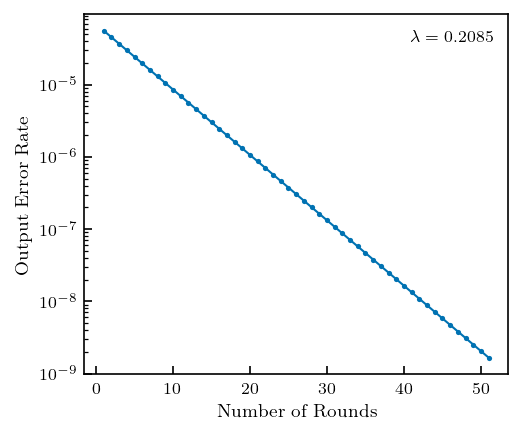

In [25]:
fig, ax = plt.subplots(figsize=(3.375, 2.8))

# Data curve, but excluded from legend
ax.plot(
    rounds_arr,
    output_error_rate_arr,
    'o-',
    color='#0072B2',
    markersize=2.5,
    linewidth=1.0,
    markeredgewidth=0.0,
    zorder=3,
    label='_nolegend_'
)

ax.set_xlabel("Number of Rounds")
ax.set_ylabel("Output Error Rate")

ax.set_yscale('log')

ax.tick_params(which='both', direction='in', top=True, right=True)
ax.tick_params(which='major', length=4)
ax.tick_params(which='minor', length=2)

# Legend with text only
dummy = plt.Line2D([], [], linestyle='none', label=rf'$\lambda={lam_fit:.4f}$')
ax.legend(
    handles=[dummy],
    frameon=False,
    loc='upper right',
    handlelength=0,
    handletextpad=0
)

# Remove ticks on the top and right
ax.tick_params(which='both', direction='in', top=False, right=False)

fig.tight_layout(pad=0.4)

# Saving Data

In [26]:
np.savez(
    "scaling.npz",
    rounds_arr=rounds_arr,
    output_error_rate_arr=output_error_rate_arr,
    lambda_=lam_fit
)